In [1]:
import functools
import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from scipy.stats import wilcoxon
from tqdm.auto import tqdm

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve()))

from constants import CAPTIONS_PATH, CVA_EM_4_PATH, ERA_EM_4_PATH, FIGURES_PATH, N_BURNIN
from obs_reconstruction import (
    NOTEBOOK_GITHUB_URL,
    make_obs_reconstruction_figure,
    run_trial,
)
from pgf_utils import (
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from system_estimate import SystemEstimate

In [2]:
# ── experiment constants ───────────────────────────────────────────────────────
N_TEST_SEEDS    = 100    # trials; seeds 10…59 (avoids training seeds 0–2)
FIRST_TEST_SEED = 10
T_TEST   = 2000         # timesteps per trial
T_BURNIN = N_BURNIN     # burn-in before recording
T_SKIP   = 100          # discard Kalman transient before scoring R²

In [3]:
# ── load estimators ───────────────────────────────────────────────────────────
ESTIMATES: list[SystemEstimate] = [
    SystemEstimate.load(CVA_EM_4_PATH),
    SystemEstimate.load(ERA_EM_4_PATH),
]
TEST_SEEDS = list(range(FIRST_TEST_SEED, FIRST_TEST_SEED + N_TEST_SEEDS))

for est in ESTIMATES:
    sr = float(np.max(np.abs(np.linalg.eigvals(est.A))))
    print(f"{est.label:20s}  n_x={est.A.shape[0]}  spectral radius: {sr:.4f}")
print(f"Test seeds: {TEST_SEEDS[0]}–{TEST_SEEDS[-1]}  (N = {N_TEST_SEEDS})")

CVA+EM $n_x=4$        n_x=4  spectral radius: 0.9410
ERA+EM $n_x=4$        n_x=4  spectral radius: 0.9719
Test seeds: 10–109  (N = 100)


In [4]:
# ── run trials in parallel ────────────────────────────────────────────────────
_run = functools.partial(
    run_trial,
    n_steps=T_TEST,
    n_burnin=T_BURNIN,
    estimates=ESTIMATES,
    t_skip=T_SKIP,
)

raw_results: list = [None] * N_TEST_SEEDS
with tqdm(total=N_TEST_SEEDS, desc="Test trials") as pbar:
    for i, res in enumerate(
        Parallel(n_jobs=-1, return_as="generator_unordered")(
            delayed(_run)(seed) for seed in TEST_SEEDS
        )
    ):
        raw_results[i] = res
        pbar.update(1)
        pbar.set_postfix(completed=i + 1)

# ── aggregate results ─────────────────────────────────────────────────────────
# raw_results[i] : dict[name -> (r2_chan (n_y,), r2f scalar)]
r2_all  = {est.name: np.stack([r[est.name][0] for r in raw_results]) for est in ESTIMATES}
r2f_all = {est.name: np.array([r[est.name][1] for r in raw_results]) for est in ESTIMATES}

data = dict(estimates=ESTIMATES, r2=r2_all, r2f=r2f_all)

# ── critical metrics ──────────────────────────────────────────────────────────
for est in ESTIMATES:
    chan_med = float(np.median(r2_all[est.name]))
    frob_med = float(np.median(r2f_all[est.name]))
    print(f"{est.label:10s}  per-channel median R² = {chan_med:.4f}"
          f"  Frobenius median R²_F = {frob_med:.4f}")

print()

# Pairwise Wilcoxon signed-rank tests on Frobenius R²
for a, b in itertools.combinations(ESTIMATES, 2):
    w, p = wilcoxon(r2f_all[a.name], r2f_all[b.name], alternative="two-sided")
    print(f"Wilcoxon {a.label} vs {b.label}:  W = {w:.1f},  p = {p:.4e}")

print()
print("Expected: ERA+EM ≥ CVA+EM >> ERA on R²_F.")

Test trials:   0%|          | 0/100 [00:00<?, ?it/s]

CVA+EM $n_x=4$  per-channel median R² = 0.3990  Frobenius median R²_F = 0.3983
ERA+EM $n_x=4$  per-channel median R² = 0.3999  Frobenius median R²_F = 0.3993

Wilcoxon CVA+EM $n_x=4$ vs ERA+EM $n_x=4$:  W = 128.0,  p = 1.6983e-16

Expected: ERA+EM ≥ CVA+EM >> ERA on R²_F.


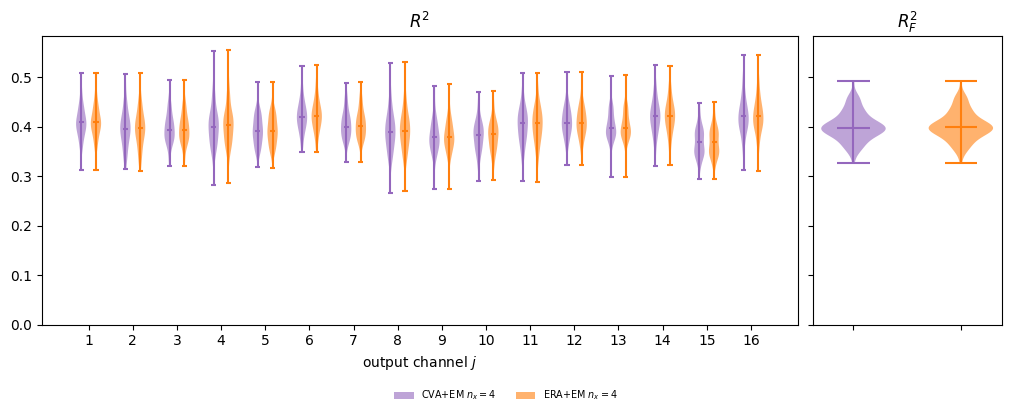

In [5]:
# ── display ────────────────────────────────────────────────────────────────────
configure_screen()
fig = make_obs_reconstruction_figure(data, figsize=(10, 4))
plt.show()

In [6]:
# ── pgf export ─────────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 1.0
FIG_HEIGHT_FRAC = 0.2

configure_pgf()
fig = make_obs_reconstruction_figure(
    data, figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC)
)
save_pgf(fig, FIGURES_PATH / "obs_reconstruction.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/obs_reconstruction.pgf


In [7]:
# ── caption ────────────────────────────────────────────────────────────────────
n_y = next(iter(r2_all.values())).shape[1]
n_x = ESTIMATES[0].A.shape[0]  # both estimators share n_x = 4

method_strs = []
for est in ESTIMATES:
    frob_med = float(np.median(r2f_all[est.name]))
    method_strs.append(rf"{est.label} $R^2_F = {frob_med:.3f}$")

caption = (
    rf"Per-channel $R^2$ (left, $n_y = {n_y}$) and Frobenius $R^2_F$ (right) "
    rf"of one-step-ahead Kalman predictions for CVA+EM and ERA+EM at $n_x = {n_x}$, "
    rf"across $N = {N_TEST_SEEDS}$ held-out trials of $T = {T_TEST}$ steps "
    rf"(first {T_SKIP} steps excluded as Kalman transient). "
    + "Median: "
    + "; ".join(method_strs)
    + "."
)

save_caption(CAPTIONS_PATH / "obs_reconstruction.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/obs_reconstruction.tex
Per-channel $R^2$ (left, $n_y = 16$) and Frobenius $R^2_F$ (right) of one-step-ahead Kalman predictions for CVA+EM and ERA+EM at $n_x = 4$, across $N = 100$ held-out trials of $T = 2000$ steps (first 100 steps excluded as Kalman transient). Median: CVA+EM $n_x=4$ $R^2_F = 0.398$; ERA+EM $n_x=4$ $R^2_F = 0.399$.
